In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
sys.path.append('..')
from pathlib import Path

import torch
from omegaconf import OmegaConf
from huggingface_hub import hf_hub_download

from configs.config import load_dataset_generation_config

mtg_ckpt_pth = Path(hf_hub_download(repo_id="abdo-eldesokey/mind-the-glitch", filename="mtg_weights.safetensors"))
mtg_config = Path(hf_hub_download(repo_id="abdo-eldesokey/mind-the-glitch", filename="experiment_cfg.yaml"))
training_cfg = OmegaConf.load(mtg_config)
dataset_cfg = load_dataset_generation_config("automated")

# Define constants from config
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = getattr(torch, training_cfg.dtype, "float32")
MODEL_NAME = training_cfg.model.name



/datawaha/cggroup/eldesoa/miniconda3/envs/mtg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


name: automated
num_imgs: 6000
dataset_path: ''
img_size:
- 768
- 768
point_idxs_to_segment:
- 0
- 10
- 20
- 30
matching_score_thresh: 0.7
matching_skewness_thresh: 1.3
part_aspect_ratio_diff_thresh: 0.2
part_relative_sz_min_thresh: 0.05
part_relative_sz_max_thresh: 0.6
part_relative_sz_diff_thresh: 0.1
inpainting_lpips_thresh: 0.15
inpainting_model: sdxl
flux_config:
  num_inference_steps: 50
  height: 512
  width: 512
  guidance_scale: 3.5
  max_sequence_length: 512
sdxl_config:
  guidance_scale: 7.5
  num_inference_steps: 30
  strength: 0.98
  padding_mask_crop: 32
  dilate_masks: false
  dilation_kernel_size: 3



In [2]:
from safetensors.torch import load_file
from torchvision import transforms
import torch

import mtg.models as mtg_models
from mtg.utils.aux_models_manager import ModelManager

# Load Auxiliary models
models_manager = ModelManager(DEVICE, dataset_cfg ,load_cleandift=True, load_groundingsam=True)
groundingdino_model, sam_predictor, cleandift_model = models_manager.groundingdino_model, models_manager.sam_predictor, models_manager.cleandift_model

transform = transforms.Compose([
                                transforms.Resize(dataset_cfg.img_size), 
                                transforms.ToTensor()])    

# Load MTG Model
model = getattr(mtg_models, MODEL_NAME)(cleandift_model, training_cfg, DEVICE, DTYPE)
print(f"Loading checkpoint from {mtg_ckpt_pth}")
if mtg_ckpt_pth.suffix == ".safetensors":
    model.load_state_dict(load_file(mtg_ckpt_pth))
else:
    model.load_state_dict(torch.load(mtg_ckpt_pth, map_location=DEVICE))
model.to(DEVICE)
model.eval()

/datawaha/cggroup/eldesoa/miniconda3/envs/mtg/lib/python3.11/site-packages/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging
/datawaha/cggroup/eldesoa/miniconda3/envs/mtg/lib/python3.11/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/datawaha/cggroup/eldesoa/code/Grounded-Segment-Anything/GroundingDINO/groundingdino/models/GroundingDINO/ms_deform_attn.py:31: UserWarning: Failed to load custom C++ ops. Running on CPU mode Only!
  warnings.warn("Failed to load custom C++ ops. Running on CPU mode Only!")


Loaded config successfully


Couldn't connect to the Hub: 404 Client Error. (Request ID: Root=1-6930786b-2ee7afd90987062a68ed81d5;268b019d-d5df-4675-a530-21785277960c)

Repository Not Found for url: https://huggingface.co/api/models/stabilityai/stable-diffusion-2-1.
Please make sure you specified the correct `repo_id` and `repo_type`.
If you are trying to access a private or gated repo, make sure you are authenticated. For more details, see https://huggingface.co/docs/huggingface_hub/authentication.
Will try to load from local cache.
Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00,  7.08it/s]


Instantiated model successfully
Downloaded weights file saved at: /home/eldesoa/.cache/huggingface/hub/models--CompVis--cleandift/snapshots/bf3a8d841ebdce7e212b61e42877f8fdaed81d58/cleandift_sd21_full.safetensors
==> Loading Grounding DINO model


final text_encoder_type: bert-base-uncased


Model loaded from /home/eldesoa/.cache/huggingface/hub/models--ShilongLiu--GroundingDINO/snapshots/a94c9b567a2a374598f05c584e96798a170c56fb/groundingdino_swinb_cogcoor.pth 
 => _IncompatibleKeys(missing_keys=[], unexpected_keys=['label_enc.weight', 'bert.embeddings.position_ids'])
==> Loading SAM model


Freezing CleanDIFT model parameters
Loading checkpoint from /home/eldesoa/.cache/huggingface/hub/models--abdo-eldesokey--mind-the-glitch/snapshots/1fcee39e49e478bfc630ca1b5966d0f8ae4e0b9c/mtg_weights.safetensors


MindTheGlitchModel(
  (cleandift_model): StableFeatureAligner(
    (ae): AutoencoderKL(
      (ae): AutoencoderKL(
        (encoder): Encoder(
          (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (down_blocks): ModuleList(
            (0): DownEncoderBlock2D(
              (resnets): ModuleList(
                (0-1): 2 x ResnetBlock2D(
                  (norm1): GroupNorm(32, 128, eps=1e-06, affine=True)
                  (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
                  (norm2): GroupNorm(32, 128, eps=1e-06, affine=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                  (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
                  (nonlinearity): SiLU()
                )
              )
              (downsamplers): ModuleList(
                (0): Downsample2D(
                  (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2)

### Run on Test Set

In [3]:
from datasets import load_dataset

dataset = load_dataset("abdo-eldesokey/mtg-dataset", split="test")


In [7]:

sample_id = 2
sample = dataset[sample_id]

img1_orig = sample["image_1_original"]
img2_orig = sample["image_2_original"]
img1_inpainted = sample["image_1_inpainted"]
img2_inpainted = sample["image_2_inpainted"]
img1_obj_mask = sample["image_1_object_mask"]
img2_obj_mask = sample["image_2_object_mask"]
img1_part_mask = sample["image_1_part_mask"]
img2_part_mask = sample["image_2_part_mask"]
    
    
img1 = img1_inpainted.resize((768, 768))
img2 = img2_orig.resize((768, 768))
model_out_dict = model.inference(img1_inpainted, img2_orig, img1_obj_mask_p=img1_obj_mask,img2_obj_mask_p=img2_obj_mask, img1_part_mask_p=img1_part_mask, img2_part_mask_p=img2_part_mask, transform=transform, return_correspondences=True)
    
metrics = model_out_dict["metrics"]
source_points_s, target_points_s, matching_score_maps_max_s = model_out_dict["source_points_s"], model_out_dict["target_points_s"], model_out_dict["matching_score_maps_max_s"]
source_points_v, target_points_v, matching_score_maps_max_v = model_out_dict["source_points_v"], model_out_dict["target_points_v"], model_out_dict["matching_score_maps_max_v"]
img1_feats_s, img2_feats_s, img1_feats_v, img2_feats_v = model_out_dict["img1_feats_s"], model_out_dict["img2_feats_s"], model_out_dict["img1_feats_v"], model_out_dict["img2_feats_v"]     


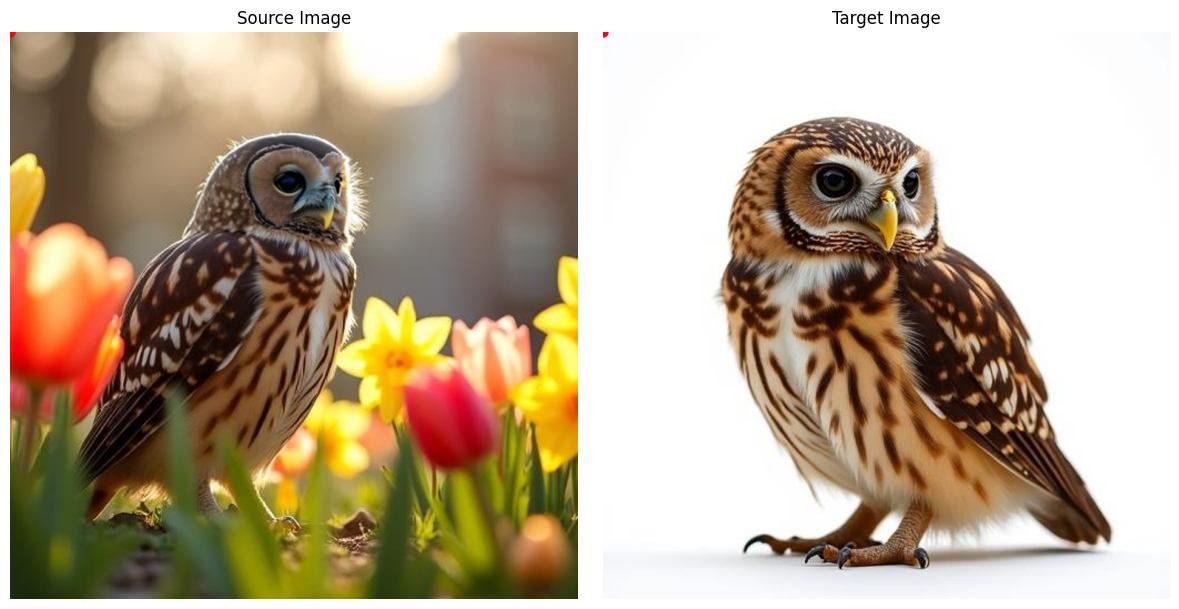

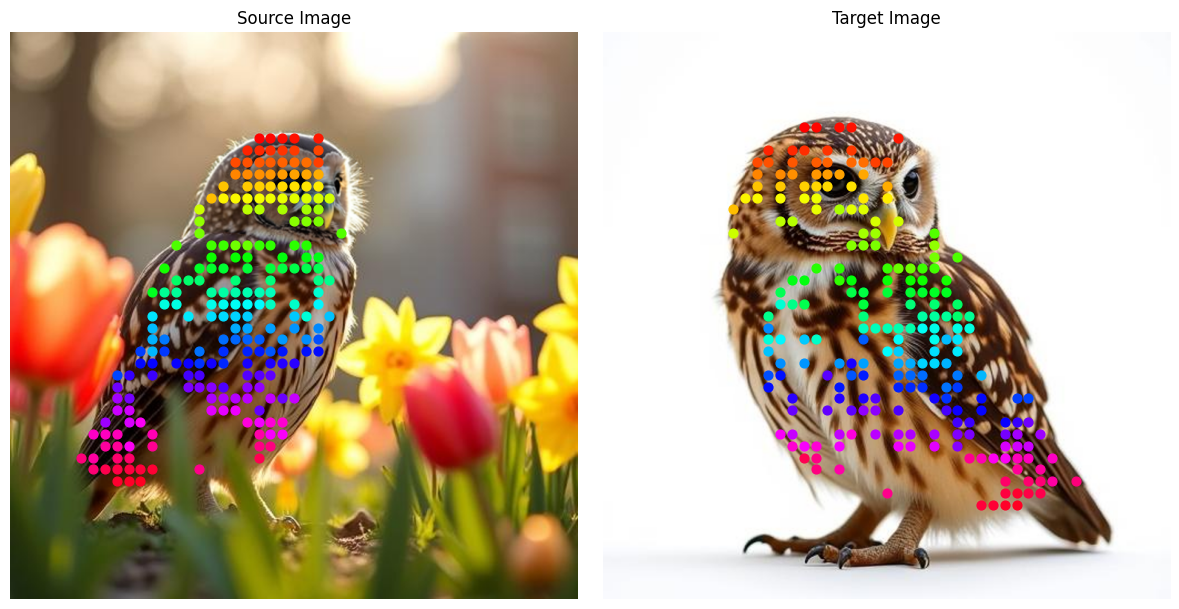

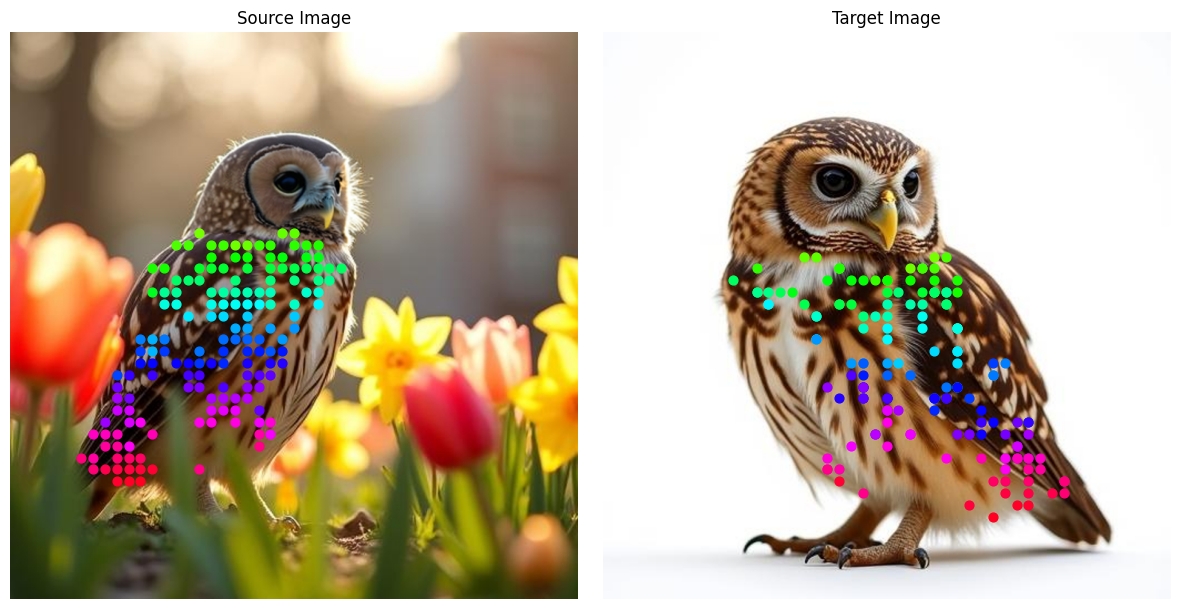

In [8]:
from mtg.utils.correspondence import compute_vsm_metric
vsm_new, correspondence_img = compute_vsm_metric(source_points_s, target_points_s, matching_score_maps_max_s, source_points_v, target_points_v, matching_score_maps_max_v,
visualize_matches=True, img1=img1, img2=img2, semantic_threshold=0.6)

### Visualize Inconsistency Maps

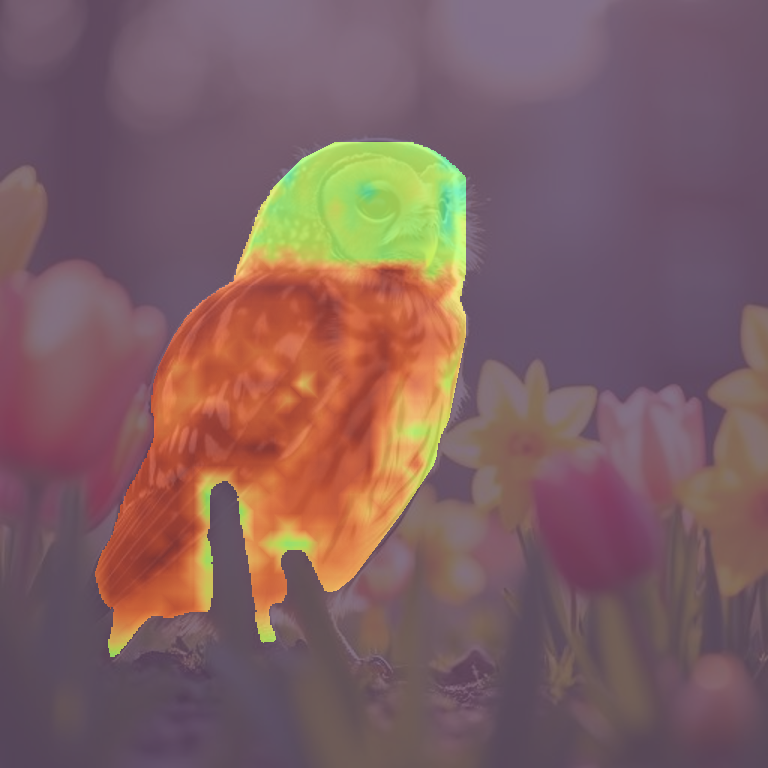

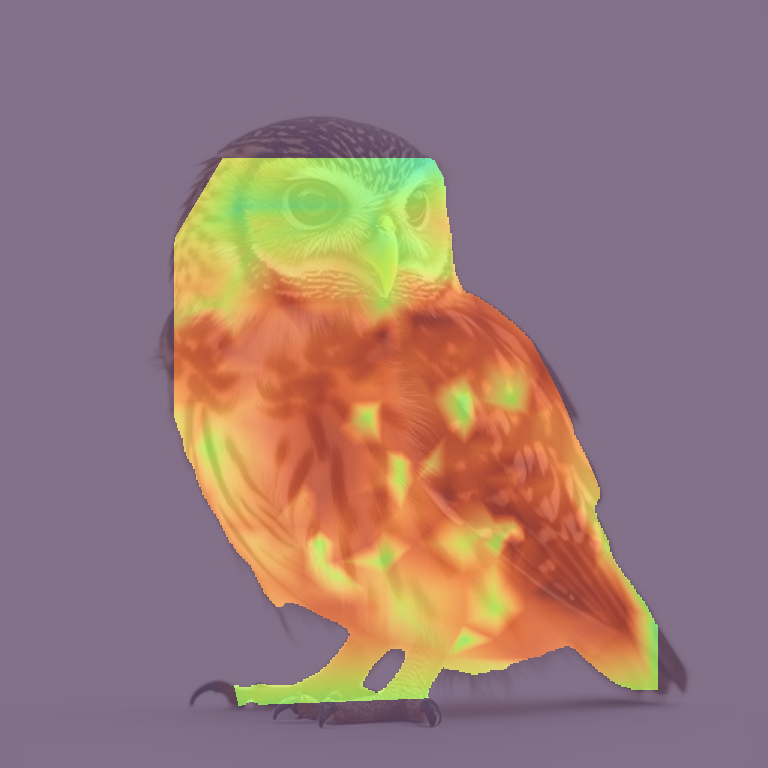

In [9]:

from IPython.display import display
from mtg.utils.visualization import plot_consistency_scores
map_1 = plot_consistency_scores(img1, img1_obj_mask, source_points_v, matching_score_maps_max_v)
map_2 = plot_consistency_scores(img2,  img2_obj_mask, target_points_v, matching_score_maps_max_v)
display(map_1)
display(map_2)


### Visualize Features

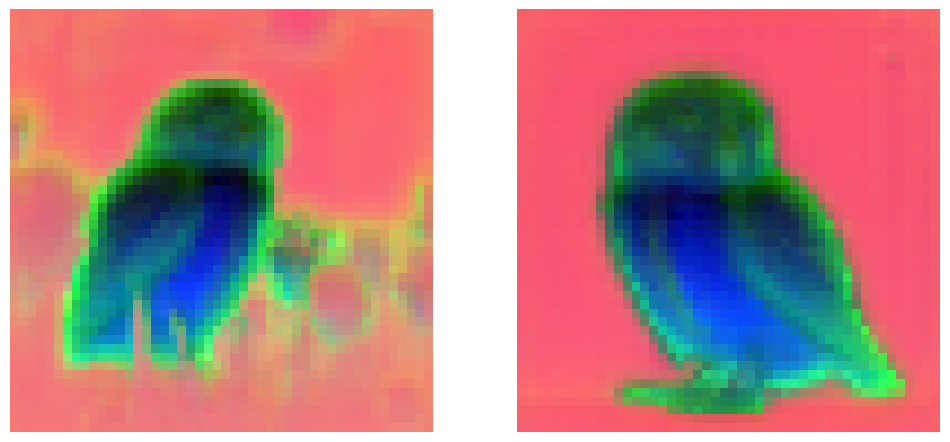

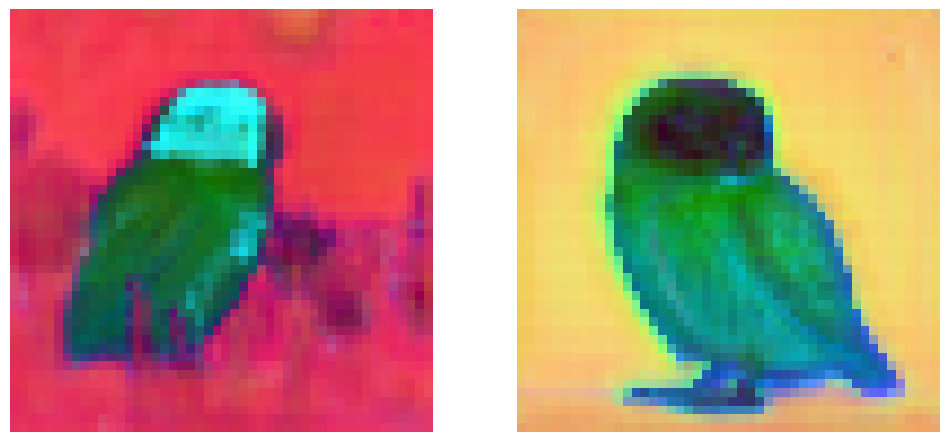

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA


flat1 = img1_feats_s[0]
flat2 = img2_feats_s[0]

for flat1, flat2, title in ((img1_feats_s[0], img2_feats_s[0], "Semantic Features"), (img1_feats_v[0], img2_feats_v[0], "Visual Feature")):
    # Step 2: Stack and normalize
    all_feats = np.vstack([flat1, flat2])
    scaler = StandardScaler()
    all_feats_scaled = scaler.fit_transform(all_feats)

    # Step 3: PCA on combined features
    pca = PCA(n_components=3)
    all_feats_pca = pca.fit_transform(all_feats_scaled)

    # Step 4: Separate and normalize each back to [0,1]
    pca1 = all_feats_pca[:flat1.shape[0]]
    pca2 = all_feats_pca[flat1.shape[0]:]

    pca1 -= pca1.min(0)
    pca1 /= pca1.max(0)
    pca2 -= pca2.min(0)
    pca2 /= pca2.max(0)

    # Step 5: Reshape to RGB images
    h, w = 48,48
    img1_rgb = pca1.reshape(h, w, 3)
    img2_rgb = pca2.reshape(h, w, 3)

    # Step 6: Display side-by-side
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img1_rgb)
    plt.axis("off")    
    plt.subplot(1, 2, 2)
    plt.imshow(img2_rgb)
    plt.axis("off")    
    plt.show()
